# Playground for Purcell calculation for linear and chiral case

In [112]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
import optomization as opt
import legume
import json 
import pickle
mpl.rcParams['text.usetex'] = False
mpl.rcParams['mathtext.fontset'] = 'cm'  # Use Computer Modern math fonts
mpl.rcParams['font.family'] = 'STIXGeneral'  # Use STIX fonts (similar to Computer Modern)
plt.rcParams.update({'font.size': 16})
plt.rcParams['text.latex.preamble'] = r'\usepackage{bm}'

#speed of light m/s
c=299792458

cs = {"y":'#ffb000',
      "o":'#fe6100',
      "m":'#dc267f',
      "p":'#785ef0',
      "b":'#648fff'}



In [113]:
# Load the saved data from GMEdata.pkl
with open('/Users/dominic/Desktop/optGME/paper2/plots/GMEdata.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)

# Unpack the data
gme, _,_ = loaded_dict['gmes']
phc, _,_ = loaded_dict['phcs']
gmeParams = loaded_dict['gmeParams']
ks = loaded_dict['ks']
gmax = loaded_dict['gmax']
ngs, _, _ = loaded_dict['ngs']

In [14]:
a = 405

backscatterParams = {'a': a,'sig':3,'lp':40,'phidiv':45,'zdiv':10}

loss = []
for i in range(200):
    loss.append(opt.backscatterLog(gme,phc,14,k=i,**backscatterParams))
loss = np.array(loss)


$$PF=\frac{3\pi c^2an_g|e\cdot n|^2}{\omega^2\sqrt{\varepsilon}}$$

In [114]:
def compute_PF(e,n,i=100,a=a,gme=gme):

    #get the different parts 
    epsilon = gme.phc.get_eps_bounds()[-1]
    a_scaled = a*1E-9
    omega = gme.freqs[i,14]*c/a_scaled*2*np.pi
    field_scale = a_scaled**3
    field_dot = e[0]*n[0] + e[1]*n[1]
    
    Purcell_ng = np.abs(field_dot)**2*3*np.pi*c**2*a_scaled/omega**2/np.sqrt(epsilon)/field_scale
    return Purcell_ng

_ = compute_PF([0,0],[0,0])


# Compute Purcell across small bandwidth for linear dipoles

$$\hat n=\hat x,\ -\hat x,\ \hat y,\ -\hat y$$

In [47]:
# set up dipoles 
x = np.array([1,0])
nx = np.array([-1,0])
y = np.array([0,1])
ny = np.array([0,-1])

#set up computation grid
x_grid = np.linspace(-50/a,50/a,100)
y_grid = np.linspace(-50/a,50/a,100)
X,Y = np.meshgrid(x_grid,y_grid)

# get the field 
field,_,_ = gme.get_field_xy('E',i,14,gme.phc.layers[0].d/2,xgrid=x_grid,ygrid=y_grid)
field = np.array([field['x'],field['y']])

In [51]:
PF_x = compute_PF(field,x)
PF_nx = compute_PF(field,nx)
PF_y = compute_PF(field,y)
PF_ny = compute_PF(field,ny)

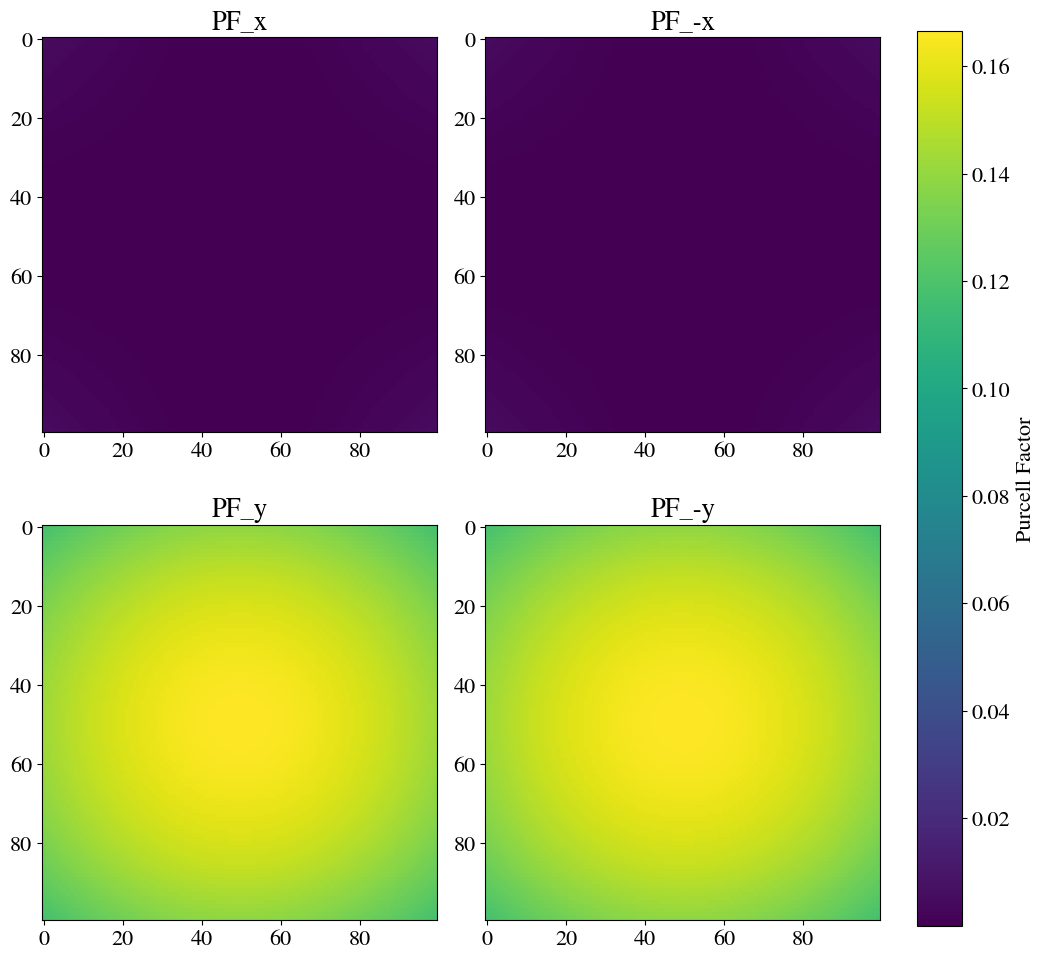

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

im0 = axes[0,0].imshow(PF_x)
axes[0,0].set_title('PF_x')
im1 = axes[0,1].imshow(PF_nx)
axes[0,1].set_title('PF_-x')
im2 = axes[1,0].imshow(PF_y)
axes[1,0].set_title('PF_y')
im3 = axes[1,1].imshow(PF_ny)
axes[1,1].set_title('PF_-y')

# Use a single colorbar for all images; use the first image as reference
# Optionally, unify vmin/vmax for comparable scales across subplots
vmin = min(np.min(PF_x), np.min(PF_nx), np.min(PF_y), np.min(PF_ny))
vmax = max(np.max(PF_x), np.max(PF_nx), np.max(PF_y), np.max(PF_ny))
for im in [im0, im1, im2, im3]:
    im.set_clim(vmin, vmax)

fig.tight_layout()
cbar = fig.colorbar(im0, ax=axes, orientation='vertical', fraction=0.05, pad=0.04)
cbar.set_label('Purcell Factor')

plt.show()

In [58]:
#look across the bandwidth for the y dipole
pfs_y_bw = []
for i in range(len(ks)):
    field,_,_ = gme.get_field_xy('E',i,14,gme.phc.layers[0].d/2,xgrid=x_grid,ygrid=y_grid)
    field = np.array([field['x'],field['y']])
    pfs = compute_PF(field,y,i=i)
    min_pf = np.min(pfs[np.sqrt((X-0)**2+(Y-0)**2)<50/a])
    pfs_y_bw.append(min_pf)
pfs_y_bw = np.array(pfs_y_bw)

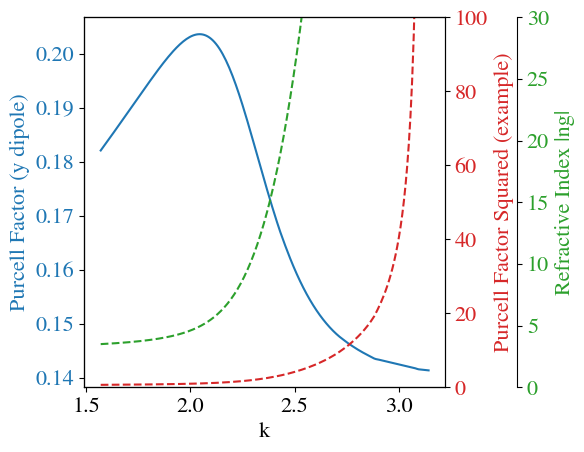

In [66]:
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.plot(ks, pfs_y_bw, color=color)
ax1.set_xlabel('k')
ax1.set_ylabel('Purcell Factor (y dipole)', color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Create a twin y-axis sharing the same x-axis
ax2 = ax1.twinx()

ax2.plot(ks, pfs_y_bw*np.abs(ngs), color='tab:red', linestyle='--')
ax2.set_ylabel('Purcell Factor Squared (example)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0,100)
# Create a third y-axis with offset to the right
from mpl_toolkits.axes_grid1 import host_subplot
import mpl_toolkits.axisartist as AA

# Offset the third y-axis using twinx/twinx with secondary axis
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.2))  # shift the spine to the right (15% past normal location)
# Make sure the new spine is visible
ax3.spines["right"].set_visible(True)

ax3.plot(ks, np.abs(ngs), color='tab:green', linestyle='--')
ax3.set_ylabel('Refractive Index |ng|', color='tab:green')
ax3.tick_params(axis='y', labelcolor='tab:green')
ax3.set_ylim(0,30)

fig.tight_layout()
plt.show()

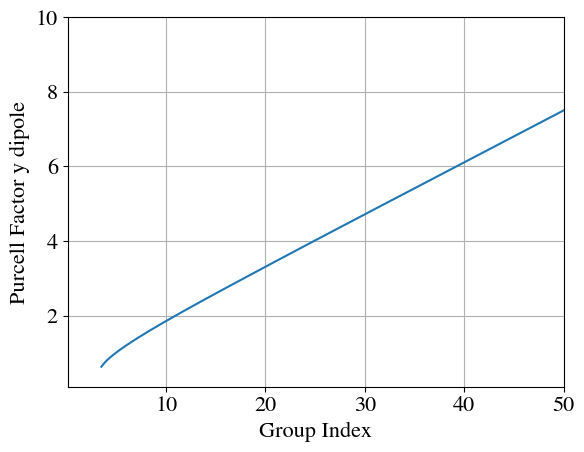

In [75]:
plt.plot(np.abs(ngs),np.abs(ngs)*pfs_y_bw)
plt.xlabel('Group Index')
plt.ylabel('Purcell Factor y dipole')
plt.xlim(0.1,50)
plt.ylim(0.1,10)
plt.grid()
plt.show()


# Compute the PF for circular dipoles

$$\hat n = \frac{\hat x + i\hat y}{\sqrt{2}},\ \frac{\hat x + i\hat y}{\sqrt{2}}$$

In [77]:
# set up dipoles 
cp = np.array([1,1j],dtype=np.complex128)/np.sqrt(2)
cn = np.array([1,-1j],dtype=np.complex128)/np.sqrt(2)

#set up computation grid
x_grid = np.linspace(-50/a,50/a,100)
y_grid = np.linspace(-50/a,50/a,100)
X,Y = np.meshgrid(x_grid,y_grid)

# get the field 
field,_,_ = gme.get_field_xy('E',100,14,gme.phc.layers[0].d/2,xgrid=x_grid,ygrid=y_grid)
field = np.array([field['x'],field['y']])

In [78]:
PF_cp = compute_PF(field,cp)
PF_cn = compute_PF(field,cn)

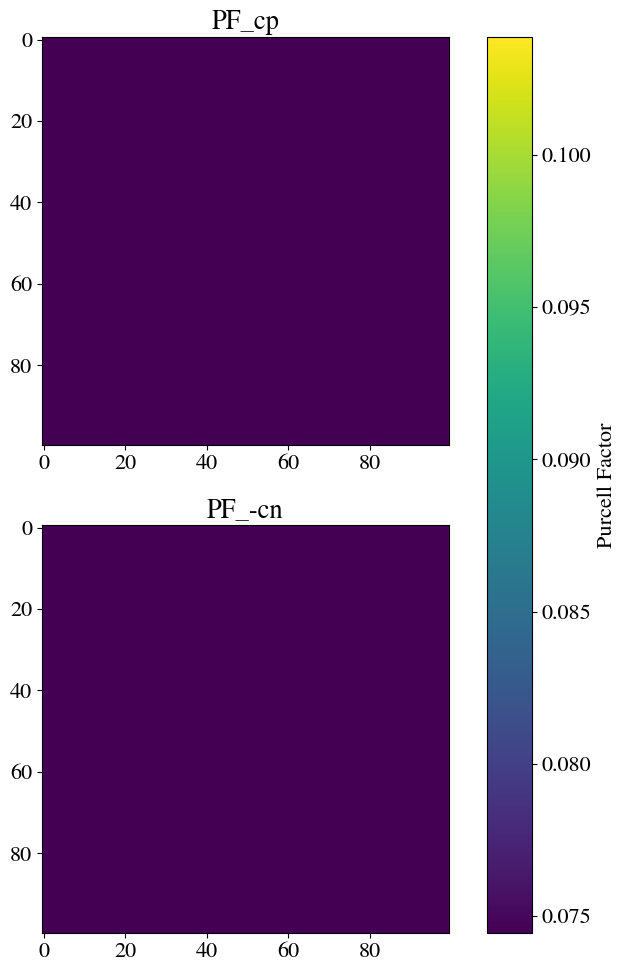

In [80]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

im0 = axes[0].imshow(PF_x)
axes[0].set_title('PF_cp')
im1 = axes[1].imshow(PF_nx)
axes[1].set_title('PF_-cn')

# Use a single colorbar for all images; use the first image as reference
# Optionally, unify vmin/vmax for comparable scales across subplots
vmin = min(np.min(PF_cp), np.min(PF_cn))
vmax = max(np.max(PF_cp), np.max(PF_cn))
for im in [im0, im1]:
    im.set_clim(vmin, vmax)

fig.tight_layout()
cbar = fig.colorbar(im0, ax=axes, orientation='vertical', fraction=0.05, pad=0.04)
cbar.set_label('Purcell Factor')

plt.show()

In [81]:
#look across the bandwidth for the y dipole
pfs_cp_bw = []
pfs_cn_bw = []
for i in range(len(ks)):
    field,_,_ = gme.get_field_xy('E',i,14,gme.phc.layers[0].d/2,xgrid=x_grid,ygrid=y_grid)
    field = np.array([field['x'],field['y']])
    pfs_cp = compute_PF(field,cp,i=i)
    pfs_cn = compute_PF(field,cn,i=i)
    min_pf_cp = np.min(pfs_cp[np.sqrt((X-0)**2+(Y-0)**2)<50/a])
    min_pf_cn = np.min(pfs_cn[np.sqrt((X-0)**2+(Y-0)**2)<50/a])
    pfs_cp_bw.append(min_pf_cp)
    pfs_cn_bw.append(min_pf_cn)
pfs_cp_bw = np.array(pfs_cp_bw)
pfs_cn_bw = np.array(pfs_cn_bw)

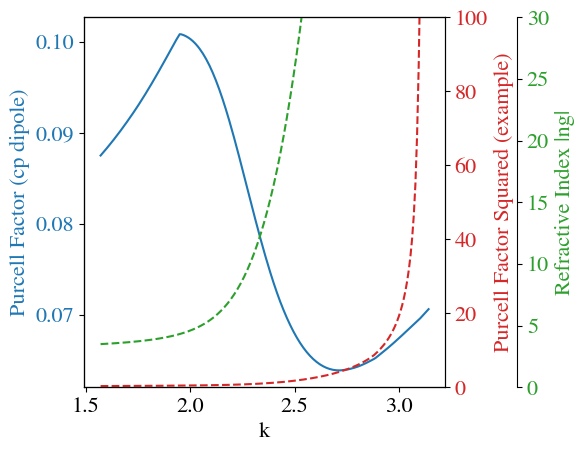

In [85]:
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.plot(ks, pfs_cp_bw, color=color)
ax1.set_xlabel('k')
ax1.set_ylabel('Purcell Factor (cp dipole)', color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Create a twin y-axis sharing the same x-axis
ax2 = ax1.twinx()

ax2.plot(ks, pfs_cp_bw*np.abs(ngs), color='tab:red', linestyle='--')
ax2.set_ylabel('Purcell Factor Squared (example)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0,100)


# Offset the third y-axis using twinx/twinx with secondary axis
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.2))  # shift the spine to the right (15% past normal location)
# Make sure the new spine is visible
ax3.spines["right"].set_visible(True)

ax3.plot(ks, np.abs(ngs), color='tab:green', linestyle='--')
ax3.set_ylabel('Refractive Index |ng|', color='tab:green')
ax3.tick_params(axis='y', labelcolor='tab:green')
ax3.set_ylim(0,30)

fig.tight_layout()
plt.show()

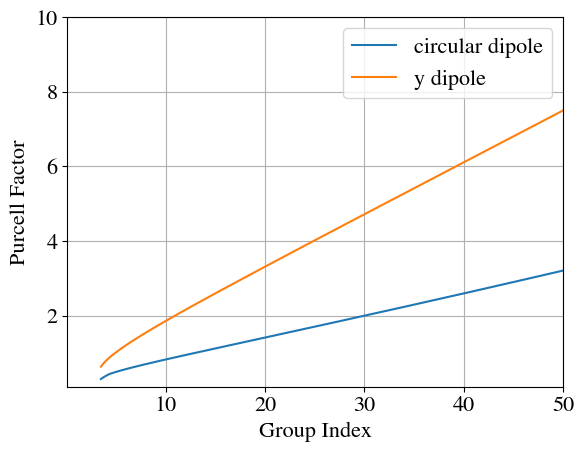

In [ ]:
plt.plot(np.abs(ngs),np.abs(ngs)*pfs_cp_bw,label='circular dipole')
plt.plot(np.abs(ngs),np.abs(ngs)*pfs_y_bw,label='y dipole')
plt.xlabel('Group Index')
plt.ylabel('Purcell Factor')
plt.legend()
plt.xlim(0.1,50)
plt.ylim(0.1,10)
plt.grid()
plt.show()

# Compute the directionality over the central area 

To get the directionality you use the two different circular dipoles $$\hat n_\pm=(\hat x\pm i\hat y)/\sqrt{2}$$ The Directionality is then $$D=\frac{PF(\hat n_+)-PF(\hat n_-)}{PF(\hat n_+)+PF(\hat n_-)}$$

In [90]:
# set up dipoles 
cp = np.array([1,1j],dtype=np.complex128)/np.sqrt(2)
cn = np.array([1,-1j],dtype=np.complex128)/np.sqrt(2)

#set up computation grid
x_grid = np.linspace(-50/a,50/a,100)
y_grid = np.linspace(-50/a,50/a,100)
X,Y = np.meshgrid(x_grid,y_grid)

# get the field 
field,_,_ = gme.get_field_xy('E',100,14,gme.phc.layers[0].d/2,xgrid=x_grid,ygrid=y_grid)
field = np.array([field['x'],field['y']])


In [91]:
PF_cp = compute_PF(field,cp)
PF_cn = compute_PF(field,cn)

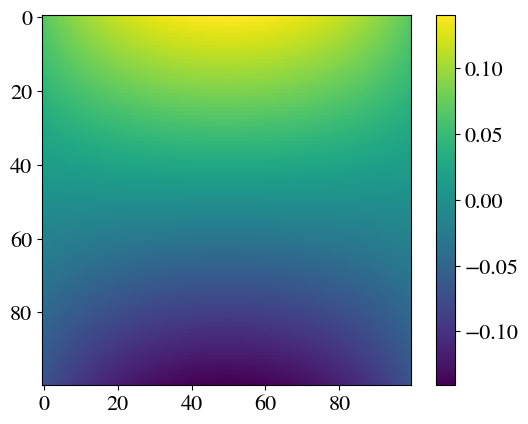

In [92]:
D = (PF_cp-PF_cn)/(PF_cp+PF_cn)
plt.imshow(D)
plt.colorbar()
plt.show()

In [97]:
#look across the bandwidth for the y dipole
minDs = []
maxDs = []
for i in range(len(ks)):
    field,_,_ = gme.get_field_xy('E',i,14,gme.phc.layers[0].d/2,xgrid=x_grid,ygrid=y_grid)
    field = np.array([field['x'],field['y']])
    pfs_cp = compute_PF(field,cp,i=i)
    pfs_cn = compute_PF(field,cn,i=i)

    D = np.abs((pfs_cp-pfs_cn)/(pfs_cp+pfs_cn))
    max_D = np.max(D[np.sqrt((X-0)**2+(Y-0)**2)<50/a])
    min_D = np.min(D[np.sqrt((X-0)**2+(Y-0)**2)<50/a])
    minDs.append(min_D)
    maxDs.append(max_D)
minDs = np.array(minDs)
maxDs = np.array(maxDs)

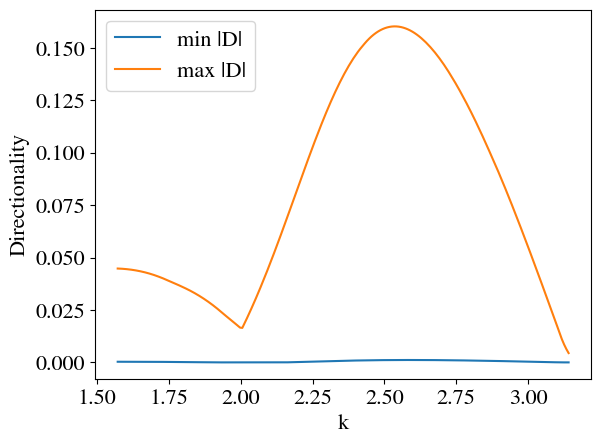

In [96]:
plt.plot(ks,minDs,label='min |D|')
plt.plot(ks,maxDs,label='max |D|')
plt.xlabel('k')
plt.ylabel('Directionality')
plt.legend()
plt.show()

In [198]:
ndbps = np.array([[0.129,0.194,0.258],[0.0645,0.0968,0.129],[0.03375,0.0484,0.0645]])

deltaKs =a/1550*ndbps

mid_usable = (.5+ks[np.where(np.abs(gme.freqs[:,14]-ks/np.pi/2)<.001)[0][0]]/2/np.pi)/2
ks_min_max = [[[mid_usable-dk/2,mid_usable+dk/2] for dk in dk_array] for dk_array in deltaKs]

ks_list = [
    [
        [
            np.where(ks/2/np.pi < k_min)[0][-1] if np.any(ks/2/np.pi < k_min) else 0,
            np.where(ks/2/np.pi > k_max)[0][0] if np.any(ks/2/np.pi > k_max) else len(ks)-1
        ]
        for k_min, k_max in k_range
    ]
    for k_range in ks_min_max
]

ks_range = [[k_max-k_min for k_min,k_max in k_range] for k_range in ks_list]
ks_range

[[27, 41, 55], [15, 21, 27], [9, 11, 15]]

In [202]:
ks_all = [[np.linspace(k_min,k_max,8,endpoint=True,dtype=int) for k_min,k_max in k_range] for k_range in ks_list]
ks_all

[[array([ 96,  99, 103, 107, 111, 115, 119, 123]),
  array([ 89,  94, 100, 106, 112, 118, 124, 130]),
  array([ 82,  89,  97, 105, 113, 121, 129, 137])],
 [array([102, 104, 106, 108, 110, 112, 114, 117]),
  array([ 99, 102, 105, 108, 111, 114, 117, 120]),
  array([ 96,  99, 103, 107, 111, 115, 119, 123])],
 [array([105, 106, 107, 108, 110, 111, 112, 114]),
  array([104, 105, 107, 108, 110, 111, 113, 115]),
  array([102, 104, 106, 108, 110, 112, 114, 117])]]

In [211]:
[
    [
        [   
            np.linspace(0,k_min,4,endpoint=True,dtype=int)[1:-1],
            np.linspace(k_max,200,4,endpoint=True,dtype=int)[1:-1]
        ] 
    for [k_min,k_max] in k_range] 
for k_range in ks_list]

[[[array([32, 64]), array([148, 174])],
  [array([29, 59]), array([153, 176])],
  [array([27, 54]), array([158, 179])]],
 [[array([34, 68]), array([144, 172])],
  [array([33, 66]), array([146, 173])],
  [array([32, 64]), array([148, 174])]],
 [[array([35, 70]), array([142, 171])],
  [array([34, 69]), array([143, 171])],
  [array([34, 68]), array([144, 172])]]]

In [209]:
np.linspace(0,10,4,endpoint=True,dtype=int)[1:-1]

array([3, 6])

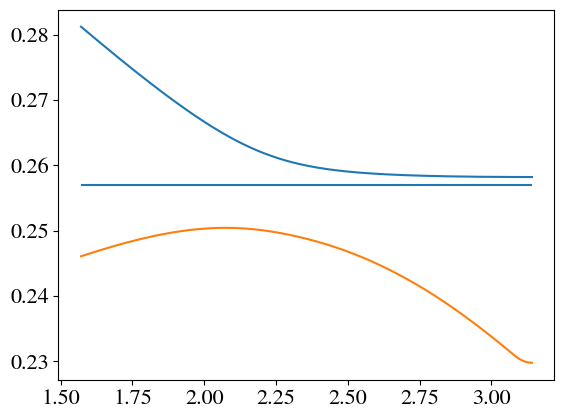

In [232]:
plt.plot(ks,gme.freqs[:,14])
plt.hlines(.257,ks[0],ks[-1])
plt.plot(ks,gme.freqs[:,13])
# plt.plot(ks[82:137],gme.freqs[82:137,14]*c/405/1E-9,'o')
# plt.hlines(c/1550/1E-9, ks[0], ks[-1])

In [ ]:
1550/1E-9

1.2702804547356171e+29